# Aprendizado Não Supervisionado

Este notebook utiliza técnicas de **aprendizado não supervisionado** sobre representações vetoriais (*embeddings*) de textos.

> **Objetivo:** O foco deste estudo **não é a classificação** (ex: prever se a notícia é falsa ou verdadeira), mas sim **analisar o comportamento, a distribuição topológica e os agrupamentos temáticos naturais** do conjunto de notícias, além de disponibilizar um **mecanismo de busca semântica por vizinhança** para encontrar as notícias mais próximas de qualquer notícia escolhida.

---

### Módulos Principais do Notebook:
1. **Carregamento e Alinhamento:** Leitura dos embeddings (`.npz`) e sincronização com os textos originais (`dataset.csv`), aplicando normalização L2 (equivalência entre distância euclidiana e similaridade de cosseno).
2. **Análise de Variância e Dimensionalidade:** Estudo da dispersão vetorial via PCA (*Scree Plot*).
3. **Exploração do Número Natural de Agrupamentos ($k$):** Avaliação de granularidade semântica para $k \in [2, 15]$ através do Método do Cotovelo (*Inércia*) e *Silhouette Score*.
4. **Benchmarking de Algoritmos de Agrupamento:**
   - **Partição:** K-Means e MiniBatch K-Means
   - **Probabilístico:** Gaussian Mixture Models (GMM)
   - **Hierárquico:** Agglomerative Clustering (com visualização de Dendrograma)
   - **Baseados em Densidade:** DBSCAN (com k-distância) e HDBSCAN
   - **Baseado em Árvore:** BIRCH
5. **Comportamento e Distribuição dos Clusters (Cluster Profiling):**
   - Distribuição de tamanho e densidade de cada cluster.
   - **Identificação da Notícia Exemplar (Medoid):** Extração do texto central de cada cluster para interpretação temática.
6. **Sistema de Busca Semântica (Notícias Mais Próximas):**
   - Consulta interativa por índice da notícia: encontra as notícias semanticamente mais próximas com métrica de similaridade de cosseno ($0\%$ a $100\%$).
   - Projeção gráfica 2D destacando a notícia escolhida e seus vizinhos imediatos.
7. **Detecção de Anomalias:** Identificação de notícias atípicas ou isoladas via Isolation Forest e LOF.
8. **Consolidação e Exportação:** Métricas comparativas, gráficos e exportação em `.csv` e `.npz`.


### 1. Importação de Bibliotecas e Configuração do Ambiente
___
**O que esta célula faz:**
Carrega bibliotecas de manipulação de dados, computação numérica, visualização e algoritmos de aprendizado não supervisionado do `scikit-learn` e `scipy`.


In [1]:
import os
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN,
    HDBSCAN,
    Birch
)
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

# Configurações de estilo e visualização
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


### 2. Configurações de Caminhos e Hiperparâmetros
___
**O que esta célula faz:**
Define os caminhos dos arquivos `.npz` e do `.csv` com os textos das notícias, além de parâmetros de exploração de clusters e controle de amostragem.

**Parâmetros configuráveis:**
* `DATA_EMBEDDINGS_PATH`: Caminho do arquivo `.npz` com os vetores.
* `DATA_CSV_PATH`: Caminho do arquivo `.csv` contendo o texto das notícias (para busca semântica e inspeção textual).
* `TARGET_K`: Quantidade de grupos semânticos/temas a serem investigados nos algoritmos de partição (não é classificação; escolha um valor como 5, 6, 8 para analisar múltiplos tópicos).
* `K_RANGE`: Intervalo de $k$ a testar na análise do cotovelo e silhueta ($2$ até $15$).
* `SAMPLE_SIZE_EVAL`: Limite de amostras para cálculos $O(N^2)$ (silhueta/t-SNE) garantindo execução ágil em bases com dezenas de milhares de amostras.


In [2]:
# Caminhos de arquivos (.npz e .csv)
DATA_EMBEDDINGS_PATH = 'data_bert_train_16_09.npz'
possible_npz_paths = [
    'data_bert_train_16_09.npz',
    os.path.join('model', 'data_bert_train_16_09.npz'),
    os.path.join('..', 'model', 'data_bert_train_16_09.npz'),
    'data_bert.npz',
    os.path.join('model', 'data_bert.npz'),
    os.path.join('..', 'model', 'data_bert.npz')
]
for p in possible_npz_paths:
    if os.path.exists(p):
        DATA_EMBEDDINGS_PATH = p
        break

DATA_CSV_PATH = '../training_data/dataset.csv'
possible_csv_paths = [
    '../training_data/dataset.csv',
    'training_data/dataset.csv',
    os.path.join('..', 'training_data', 'dataset.csv'),
    os.path.join('training_data', 'dataset.csv'),
    'dataset.csv'
]
for p in possible_csv_paths:
    if os.path.exists(p):
        DATA_CSV_PATH = p
        break

OUTPUT_DIR = 'results_unsupervised'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hiperparâmetros de exploração temática
RANDOM_STATE = 42
TARGET_K = 4           # Número de temas/tópicos latentes para particionamento inicial (ajustável)
K_RANGE = range(2, 16) # Intervalo para análise de cotovelo e silhueta
SAMPLE_SIZE_EVAL = 5000
APPLY_PCA_PRE_CLUSTERING = True
PCA_DIMS = 100

print(f"Arquivo NPZ: {DATA_EMBEDDINGS_PATH}")
print(f"Arquivo CSV: {DATA_CSV_PATH}")
print(f"Diretório de saída: {OUTPUT_DIR}")
print(f"TARGET_K inicial: {TARGET_K} | Intervalo de K: [{min(K_RANGE)}, {max(K_RANGE)}]")


Arquivo NPZ: data_bert_train_16_09.npz
Arquivo CSV: ../training_data/dataset.csv
Diretório de saída: results_unsupervised
TARGET_K inicial: 4 | Intervalo de K: [2, 15]


### 3. Carregamento dos Embeddings e Associação com os Textos das Notícias
___
**O que esta célula faz:**
1. **Leitura dos Vetores (.npz):** Carrega a matriz de embeddings $X$ e rótulos de referência opcionais $y$.
2. **Associação com os Textos (.csv):** Carrega o texto original das notícias do CSV (garantindo correspondência com a divisão estratificada utilizada na geração dos embeddings).
3. **Normalização L2:** Normaliza cada vetor para ter norma unitária ($\|x\|_2 = 1$). Com isso:
$$\|u - v\|^2 = 2 - 2 \cos(u, v)$$
A distância euclidiana torna-se uma transformação direta da similaridade de cosseno, otimizando algoritmos baseados em distância para vetores de linguagem.


In [3]:
from sklearn.model_selection import train_test_split

# 1. Carregamento dos embeddings (.npz)
if os.path.exists(DATA_EMBEDDINGS_PATH):
    print(f"Carregando embeddings de '{DATA_EMBEDDINGS_PATH}'...")
    npz_data = np.load(DATA_EMBEDDINGS_PATH, allow_pickle=True)
    print(f"Chaves disponíveis no .npz: {list(npz_data.files)}")

    emb_key = next((k for k in ['embeddings', 'X', 'features'] if k in npz_data.files), None)
    lbl_key = next((k for k in ['labels', 'y', 'label'] if k in npz_data.files), None)

    X_raw = npz_data[emb_key].astype(np.float32)
    y_true = npz_data[lbl_key] if lbl_key is not None else None
    print(f"Embeddings carregados: {X_raw.shape}")
else:
    print(f"Arquivo '{DATA_EMBEDDINGS_PATH}' não encontrado. Gerando dados sintéticos demonstrativos...")
    from sklearn.datasets import make_blobs
    X_raw, y_true = make_blobs(n_samples=2500, n_features=768, centers=TARGET_K, cluster_std=3.0, random_state=RANDOM_STATE)
    X_raw = X_raw.astype(np.float32)

# 2. Carregamento e alinhamento dos textos das notícias
news_texts = []
if os.path.exists(DATA_CSV_PATH):
    print(f"Carregando textos de '{DATA_CSV_PATH}'...")
    df_full = pd.read_csv(DATA_CSV_PATH)
    if 'text' in df_full.columns:
        if len(df_full) == len(X_raw):
            news_texts = df_full['text'].astype(str).tolist()
        elif len(df_full) > len(X_raw) and y_true is not None:
            # Sincronização com o train_test_split estratificado utilizado na criação do .npz
            df_train, _ = train_test_split(df_full, train_size=len(X_raw), random_state=42, stratify=df_full['label'])
            news_texts = df_train['text'].astype(str).tolist()
        else:
            news_texts = df_full['text'].iloc[:len(X_raw)].astype(str).tolist()
        print(f"Textos das notícias vinculados com sucesso: {len(news_texts)} notícias.")
else:
    print("CSV de textos não encontrado. Criando referências de texto sintéticas...")
    news_texts = [f"Notícia #{i} - Texto sintético sobre o tópico {y_true[i] if y_true is not None else ''}" for i in range(len(X_raw))]

# Verificação numérica
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=1e6, neginf=-1e6)

# Normalização L2 unitária
X = normalize(X_raw, norm='l2')
print(f"Matriz de embeddings processada X: {X.shape} | Norma média: {np.linalg.norm(X, axis=1).mean():.4f}")


Carregando embeddings de 'data_bert_train_16_09.npz'...
Chaves disponíveis no .npz: ['embeddings', 'labels']
Embeddings carregados: (39219, 772)
Carregando textos de '../training_data/dataset.csv'...
Textos das notícias vinculados com sucesso: 39219 notícias.
Matriz de embeddings processada X: (39219, 772) | Norma média: 1.0000


### 4. Análise de Variância e Estrutura Dimensional (PCA)
___
**O que esta célula faz:**
Examina a distribuição de variância ao longo dos componentes principais. Avalia se os embeddings concentram a informação semântica em um subespaço de menor dimensão, reduzindo o ruído para as etapas subsequentes.


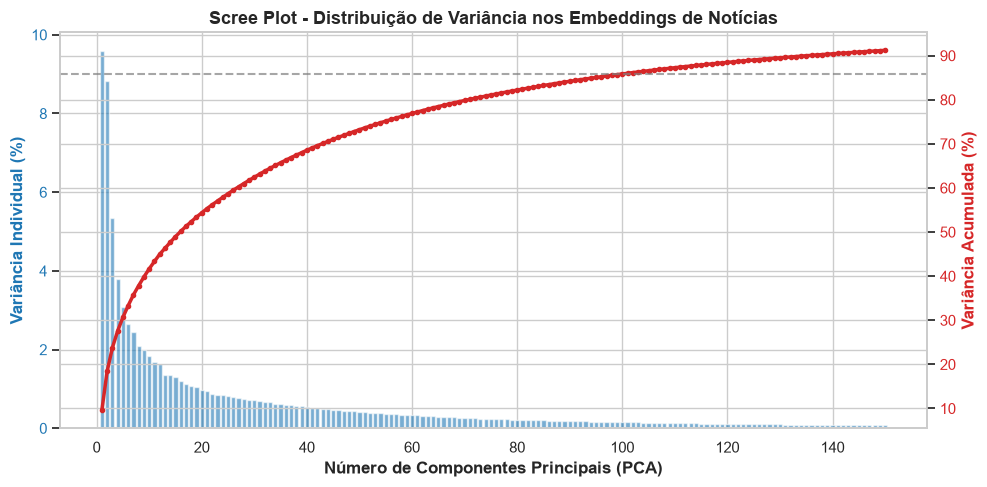

Dimensão reduzida X_pca: (39219, 100) (Variância preservada: 85.86%)
Considerando apenas 2 componentes principais, variância preservada: 18.41%


In [4]:

n_comp = min(150, X.shape[1], X.shape[0] - 1)
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
pca.fit(X)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de Componentes Principais (PCA)', fontweight='bold')
ax1.set_ylabel('Variância Individual (%)', color=color, fontweight='bold')
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_ * 100, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Variância Acumulada (%)', color=color, fontweight='bold')
ax2.plot(range(1, len(cum_var) + 1), cum_var, color=color, linewidth=2.5, marker='o', markersize=3)
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=85.86, color='gray', linestyle='--', alpha=0.7, label='85.86% de Variância')

plt.title('Scree Plot - Distribuição de Variância nos Embeddings de Notícias', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# Projeção intermediária para aceleração dos algoritmos de vizinhança e densidade
pca_red = PCA(n_components=min(PCA_DIMS, X.shape[1]), random_state=RANDOM_STATE)
X_pca = pca_red.fit_transform(X)
print(f"Dimensão reduzida X_pca: {X_pca.shape} (Variância preservada: {pca_red.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"Considerando apenas 2 componentes principais, variância preservada: {PCA(n_components=2, random_state=RANDOM_STATE).fit(X).explained_variance_ratio_.sum()*100:.2f}%")


### 5. Exploração do Número de Grupos Temáticos ($k \in [2, 15]$)
___
**O que esta célula faz:**
Como o objetivo é analisar a estrutura temática natural das notícias (e não forçar 2 classes), testamos uma faixa ampla de $k \in [2, 15]$ usando apenas o **Método do Cotovelo** (*Inércia / WCSS*):
* **Inércia:** Mede a compacidade dos grupos. A escolha do ponto de inflexão no gráfico indica o número natural de clusters.

> Nesta versão do notebook, o critério de seleção de $k$ foi reduzido ao teste do cotovelo, descartando Silhouette e Davies-Bouldin como critérios de escolha do número de agrupamentos.


Calculando inércia para k de 2 a 15 usando 5000 amostras...
k =  2 | Inércia:    2148.90
k =  3 | Inércia:    2021.55
k =  4 | Inércia:    1910.47
k =  5 | Inércia:    1864.44
k =  6 | Inércia:    1831.60
k =  7 | Inércia:    1793.31
k =  8 | Inércia:    1764.89
k =  9 | Inércia:    1726.63
k = 10 | Inércia:    1710.87
k = 11 | Inércia:    1692.18
k = 12 | Inércia:    1656.89
k = 13 | Inércia:    1625.43
k = 14 | Inércia:    1617.39
k = 15 | Inércia:    1605.18


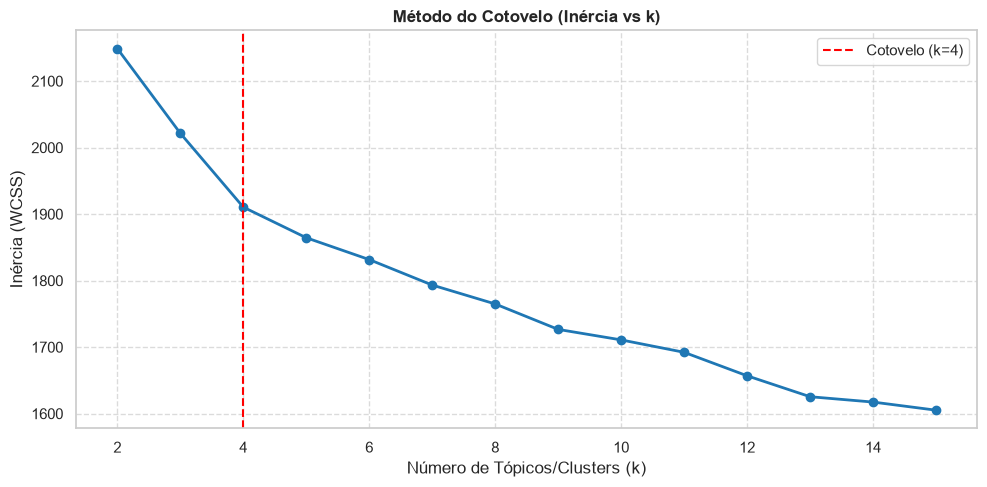

Sugestão de k pelo método do cotovelo: k = 4


In [5]:
inertias = []

if len(X) > SAMPLE_SIZE_EVAL:
    np.random.seed(RANDOM_STATE)
    idx_eval = np.random.choice(len(X), SAMPLE_SIZE_EVAL, replace=False)
    X_k_eval = X[idx_eval]
else:
    X_k_eval = X

print(f"Calculando inércia para k de {min(K_RANGE)} a {max(K_RANGE)} usando {len(X_k_eval)} amostras...")

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE)
    lbls = km.fit_predict(X_k_eval)

    inertias.append(km.inertia_)
    print(f"k = {k:2d} | Inércia: {km.inertia_:10.2f}")

fig, ax = plt.subplots(figsize=(10, 5))

# Gráfico 1: Inércia (Cotovelo)
ax.plot(list(K_RANGE), inertias, marker='o', color='tab:blue', linewidth=2)

# Escolha do ponto de cotovelo pela maior curvatura da curva de inércia
# (não pela maior diferença absoluta, que tende a favorecer o primeiro k)
if len(inertias) > 3:
    inertia_arr = np.asarray(inertias, dtype=float)
    curvature = np.abs(np.diff(inertia_arr, n=2))
    elbow_index = np.argmax(curvature) + 1
    best_elbow_k = list(K_RANGE)[elbow_index]
else:
    best_elbow_k = min(K_RANGE)

ax.axvline(x=best_elbow_k, color='red', linestyle='--', label=f'Cotovelo (k={best_elbow_k})')
ax.set_title('Método do Cotovelo (Inércia vs k)', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Tópicos/Clusters (k)')
ax.set_ylabel('Inércia (WCSS)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Sugestão de k pelo método do cotovelo: k = {best_elbow_k}")
# Caso deseje adotar o valor sugerido pelo cotovelo, descomente:
TARGET_K = best_elbow_k


### 6. Pipeline Unificado de Avaliação dos Agrupamentos
___
**O que esta célula faz:**
Padroniza o registro de métricas de qualidade intrínseca de cada algoritmo testado:
* **Silhouette Score:** Coesão intra-cluster vs. separação inter-cluster.
* **Davies-Bouldin:** Similaridade mútua entre clusters.
* **Calinski-Harabasz:** Razão de dispersão entre/dentro dos clusters.
* **Taxa de Ruído (%):** Percentual de notícias isoladas (rótulo `-1` em DBSCAN/HDBSCAN).


In [6]:
unsupervised_results = []
predicted_cluster_labels = {}

def evaluate_unsupervised_model(model_name, labels, X_features, y_ref=None, fit_time_sec=0.0):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1])
    n_noise = int(np.sum(labels == -1))
    noise_ratio = float(n_noise / len(labels)) * 100

    valid_mask = labels != -1 if n_noise > 0 else np.ones(len(labels), dtype=bool)
    n_valid = np.sum(valid_mask)

    sil, db, ch = np.nan, np.nan, np.nan

    if n_clusters >= 2 and n_valid > n_clusters:
        X_eval = X_features[valid_mask]
        lbl_eval = labels[valid_mask]

        sample_lim = min(SAMPLE_SIZE_EVAL, len(X_eval))
        if len(X_eval) > sample_lim:
            idx = np.random.choice(len(X_eval), sample_lim, replace=False)
            sil = float(silhouette_score(X_eval[idx], lbl_eval[idx]))
        else:
            sil = float(silhouette_score(X_eval, lbl_eval))

        db = float(davies_bouldin_score(X_eval, lbl_eval))
        ch = float(calinski_harabasz_score(X_eval, lbl_eval))

    ari, nmi, v_meas = np.nan, np.nan, np.nan
    if y_ref is not None and n_clusters >= 2:
        y_valid = y_ref[valid_mask]
        lbl_eval = labels[valid_mask]
        ari = float(adjusted_rand_score(y_valid, lbl_eval))
        nmi = float(normalized_mutual_info_score(y_valid, lbl_eval))
        v_meas = float(v_measure_score(y_valid, lbl_eval))

    res = {
        'Model': model_name,
        'N_Clusters': n_clusters,
        'Noise_Count': n_noise,
        'Noise_Ratio_%': round(noise_ratio, 2),
        'Silhouette': round(sil, 4) if not np.isnan(sil) else None,
        'Davies_Bouldin': round(db, 4) if not np.isnan(db) else None,
        'Calinski_Harabasz': round(ch, 2) if not np.isnan(ch) else None,
        'ARI_Ref': round(ari, 4) if not np.isnan(ari) else None,
        'Fit_Time_Sec': round(fit_time_sec, 3)
    }

    unsupervised_results.append(res)
    predicted_cluster_labels[model_name] = labels

    print(f"[{model_name}] Clusters formados: {n_clusters} | Ruído: {noise_ratio:.1f}% | Tempo: {fit_time_sec:.2f}s")
    print(f"   -> Silhueta: {res['Silhouette']} | Davies-Bouldin: {res['Davies_Bouldin']} | Calinski-Harabasz: {res['Calinski_Harabasz']}")
    print("-" * 65)
    return res

print("Pipeline de avaliação inicializado.")


Pipeline de avaliação inicializado.


### 7. Algoritmos de Partição e Probabilísticos (K-Means, MiniBatchKMeans, GMM)
___
**O que esta célula faz:**
Aplica três dos principais algoritmos de partição vetorial:
1. **K-Means:** Agrupamento por centróides iterativos via distância euclidiana nos embeddings normalizados.
2. **MiniBatch K-Means:** Versão com mini-lotes estocásticos, altamente veloz em bases volumosas.
3. **Gaussian Mixture Model (GMM):** Agrupamento probabilístico que modela a distribuição dos dados como uma mistura de gaussianas multidimensionais.


In [7]:
# 1. K-Means
t0 = time.time()
kmeans = KMeans(n_clusters=TARGET_K, init='k-means++', random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X)
evaluate_unsupervised_model('K-Means', labels_kmeans, X, y_true, fit_time_sec=time.time() - t0)

# 2. MiniBatch K-Means
t0 = time.time()
mb_kmeans = MiniBatchKMeans(n_clusters=TARGET_K, batch_size=1024, n_init=10, random_state=RANDOM_STATE)
labels_mb_kmeans = mb_kmeans.fit_predict(X)
evaluate_unsupervised_model('MiniBatch K-Means', labels_mb_kmeans, X, y_true, fit_time_sec=time.time() - t0)

# 3. Gaussian Mixture Model (GMM)
t0 = time.time()
gmm_feats = X_pca if APPLY_PCA_PRE_CLUSTERING else X
gmm = GaussianMixture(n_components=TARGET_K, covariance_type='diag', random_state=RANDOM_STATE)
labels_gmm = gmm.fit_predict(gmm_feats)
evaluate_unsupervised_model('Gaussian Mixture (GMM)', labels_gmm, X, y_true, fit_time_sec=time.time() - t0)


[K-Means] Clusters formados: 4 | Ruído: 0.0% | Tempo: 0.86s
   -> Silhueta: 0.085 | Davies-Bouldin: 2.9828 | Calinski-Harabasz: 2794.14
-----------------------------------------------------------------
[MiniBatch K-Means] Clusters formados: 4 | Ruído: 0.0% | Tempo: 1.26s
   -> Silhueta: 0.0777 | Davies-Bouldin: 3.524 | Calinski-Harabasz: 2423.46
-----------------------------------------------------------------
[Gaussian Mixture (GMM)] Clusters formados: 4 | Ruído: 0.0% | Tempo: 28.11s
   -> Silhueta: 0.0457 | Davies-Bouldin: 3.7413 | Calinski-Harabasz: 1897.63
-----------------------------------------------------------------


{'Model': 'Gaussian Mixture (GMM)',
 'N_Clusters': 4,
 'Noise_Count': 0,
 'Noise_Ratio_%': 0.0,
 'Silhouette': 0.0457,
 'Davies_Bouldin': 3.7413,
 'Calinski_Harabasz': 1897.63,
 'ARI_Ref': 0.1288,
 'Fit_Time_Sec': 28.115}

### 8. Agrupamento Hierárquico Aglomerativo e Dendrograma
___
**O que esta célula faz:**
1. Gera um **Dendrograma Truncado** para uma amostra representativa de notícias, ilustrando a hierarquia de fusão dos temas.
2. Executa o **Agglomerative Clustering** com critério de ligação *Ward* (minimiza o aumento da variância total a cada fusão).


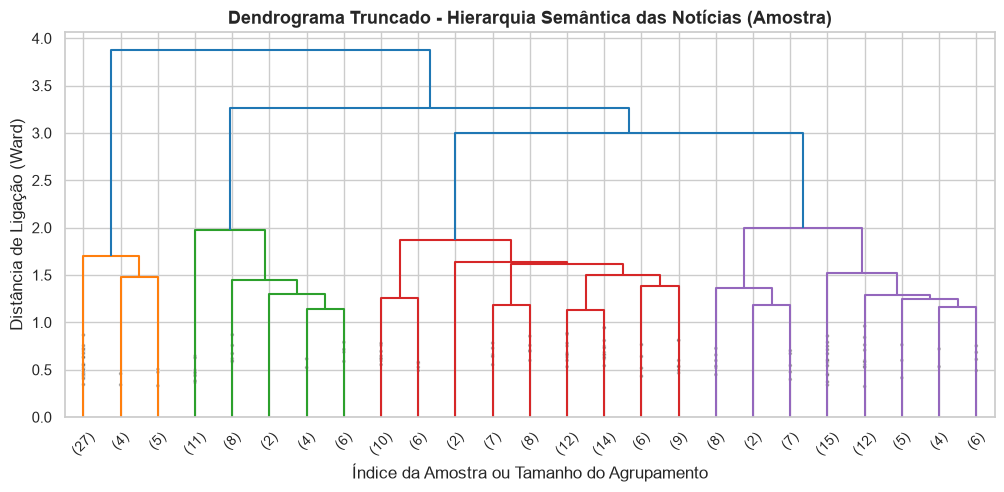

[Agglomerative (Ward)] Clusters formados: 4 | Ruído: 0.0% | Tempo: 1.40s
   -> Silhueta: 0.0715 | Davies-Bouldin: 3.268 | Calinski-Harabasz: 2451.23
-----------------------------------------------------------------


{'Model': 'Agglomerative (Ward)',
 'N_Clusters': 4,
 'Noise_Count': 0,
 'Noise_Ratio_%': 0.0,
 'Silhouette': 0.0715,
 'Davies_Bouldin': 3.268,
 'Calinski_Harabasz': 2451.23,
 'ARI_Ref': 0.2196,
 'Fit_Time_Sec': 1.397}

In [8]:
# Amostragem para construção do dendrograma
dendro_sample_size = min(200, len(X))
np.random.seed(RANDOM_STATE)
idx_dendro = np.random.choice(len(X), dendro_sample_size, replace=False)
X_dendro = X_pca[idx_dendro] if APPLY_PCA_PRE_CLUSTERING else X[idx_dendro]

linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=25,
    leaf_rotation=45.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrograma Truncado - Hierarquia Semântica das Notícias (Amostra)', fontsize=13, fontweight='bold')
plt.xlabel('Índice da Amostra ou Tamanho do Agrupamento')
plt.ylabel('Distância de Ligação (Ward)')
plt.show()

# Agglomerative Clustering (utiliza amostragem representativa se N > 5000 para evitar O(N^2) de memória/tempo)
t0 = time.time()
sample_agg = min(5000, len(X))
if len(X) > sample_agg:
    np.random.seed(RANDOM_STATE)
    idx_agg = np.random.choice(len(X), sample_agg, replace=False)
    agg_feats_sample = X_pca[idx_agg] if APPLY_PCA_PRE_CLUSTERING else X[idx_agg]
    agg = AgglomerativeClustering(n_clusters=TARGET_K, metric='euclidean', linkage='ward')
    labels_agg_sample = agg.fit_predict(agg_feats_sample)

    knn_prop = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(agg_feats_sample)
    _, nearest_idx = knn_prop.kneighbors(X_pca if APPLY_PCA_PRE_CLUSTERING else X)
    labels_agg = labels_agg_sample[nearest_idx.flatten()]
else:
    agg_feats = X_pca if APPLY_PCA_PRE_CLUSTERING else X
    agg = AgglomerativeClustering(n_clusters=TARGET_K, metric='euclidean', linkage='ward')
    labels_agg = agg.fit_predict(agg_feats)

evaluate_unsupervised_model('Agglomerative (Ward)', labels_agg, X, y_true, fit_time_sec=time.time() - t0)


### 9. Agrupamento Baseado em Densidade (DBSCAN & HDBSCAN)
___
**O que esta célula faz:**
1. **Gráfico de k-distância:** Plota a distância ordenada ao $k$-ésimo vizinho para guiar a escolha de $\epsilon$ no DBSCAN.
2. **DBSCAN:** Agrupa notícias localizadas em regiões de densidade contínua e rotula notícias isoladas como ruído (`-1`). Não exige especificar o número de clusters a priori.
3. **HDBSCAN:** Abordagem hierárquica por densidade que descobre clusters com diferentes densidades e formas arbitrárias de maneira automática.


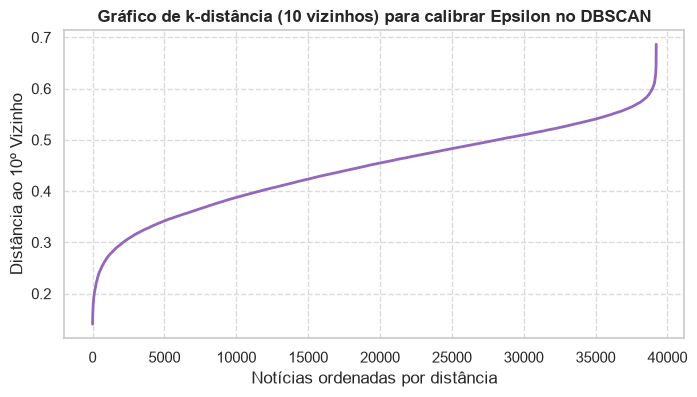

[DBSCAN] Clusters formados: 6 | Ruído: 3.1% | Tempo: 2.77s
   -> Silhueta: 0.0999 | Davies-Bouldin: 1.594 | Calinski-Harabasz: 293.66
-----------------------------------------------------------------
[HDBSCAN] Clusters formados: 4 | Ruído: 2.4% | Tempo: 6.09s
   -> Silhueta: 0.0999 | Davies-Bouldin: 1.567 | Calinski-Harabasz: 483.06
-----------------------------------------------------------------


{'Model': 'HDBSCAN',
 'N_Clusters': 4,
 'Noise_Count': 955,
 'Noise_Ratio_%': 2.44,
 'Silhouette': 0.0999,
 'Davies_Bouldin': 1.567,
 'Calinski_Harabasz': 483.06,
 'ARI_Ref': -0.0131,
 'Fit_Time_Sec': 6.091}

In [9]:
# Gráfico de k-distância
k_neighbors = 10
nbrs = NearestNeighbors(n_neighbors=k_neighbors, metric='euclidean').fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
dist_sorted = np.sort(distances[:, k_neighbors - 1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='tab:purple', linewidth=2)
plt.title(f'Gráfico de k-distância ({k_neighbors} vizinhos) para calibrar Epsilon no DBSCAN', fontsize=12, fontweight='bold')
plt.xlabel('Notícias ordenadas por distância')
plt.ylabel(f'Distância ao {k_neighbors}º Vizinho')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 1. DBSCAN
t0 = time.time()
eps_est = float(np.percentile(dist_sorted, 85))
dbscan = DBSCAN(eps=eps_est, min_samples=10, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X_pca)
evaluate_unsupervised_model('DBSCAN', labels_dbscan, X, y_true, fit_time_sec=time.time() - t0)

# 2. HDBSCAN (amostragem representativa se N > 8000 para agilidade no grafo de densidade)
t0 = time.time()
sample_hdb = min(8000, len(X))
if len(X) > sample_hdb:
    np.random.seed(RANDOM_STATE)
    idx_hdb = np.random.choice(len(X), sample_hdb, replace=False)
    hdb_feats_sample = X_pca[idx_hdb] if APPLY_PCA_PRE_CLUSTERING else X[idx_hdb]
    hdb = HDBSCAN(min_cluster_size=25, min_samples=10, metric='euclidean')
    labels_hdb_sample = hdb.fit_predict(hdb_feats_sample)

    knn_prop_hdb = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(hdb_feats_sample)
    _, near_hdb = knn_prop_hdb.kneighbors(X_pca if APPLY_PCA_PRE_CLUSTERING else X)
    labels_hdbscan = labels_hdb_sample[near_hdb.flatten()]
else:
    hdbscan = HDBSCAN(min_cluster_size=25, min_samples=10, metric='euclidean')
    labels_hdbscan = hdbscan.fit_predict(X_pca)

evaluate_unsupervised_model('HDBSCAN', labels_hdbscan, X, y_true, fit_time_sec=time.time() - t0)


### 10. Agrupamento Baseado em Árvore de Recursos (BIRCH)
___
**O que esta célula faz:**
O **BIRCH** constrói uma árvore compacta de subclusters (*Clustering Feature Tree*) em passagem linear pelos dados, sendo ideal para grandes coleções de texto.


In [10]:
t0 = time.time()
birch_feats = X_pca if APPLY_PCA_PRE_CLUSTERING else X
birch = Birch(n_clusters=TARGET_K, threshold=0.3, branching_factor=50)
labels_birch = birch.fit_predict(birch_feats)
evaluate_unsupervised_model('BIRCH', labels_birch, X, y_true, fit_time_sec=time.time() - t0)


[BIRCH] Clusters formados: 4 | Ruído: 0.0% | Tempo: 19.42s
   -> Silhueta: 0.0686 | Davies-Bouldin: 3.1564 | Calinski-Harabasz: 2355.1
-----------------------------------------------------------------


{'Model': 'BIRCH',
 'N_Clusters': 4,
 'Noise_Count': 0,
 'Noise_Ratio_%': 0.0,
 'Silhouette': 0.0686,
 'Davies_Bouldin': 3.1564,
 'Calinski_Harabasz': 2355.1,
 'ARI_Ref': 0.2178,
 'Fit_Time_Sec': 19.416}

#### 11. Comportamento e Distribuição dos Clusters (Cluster Profiling)

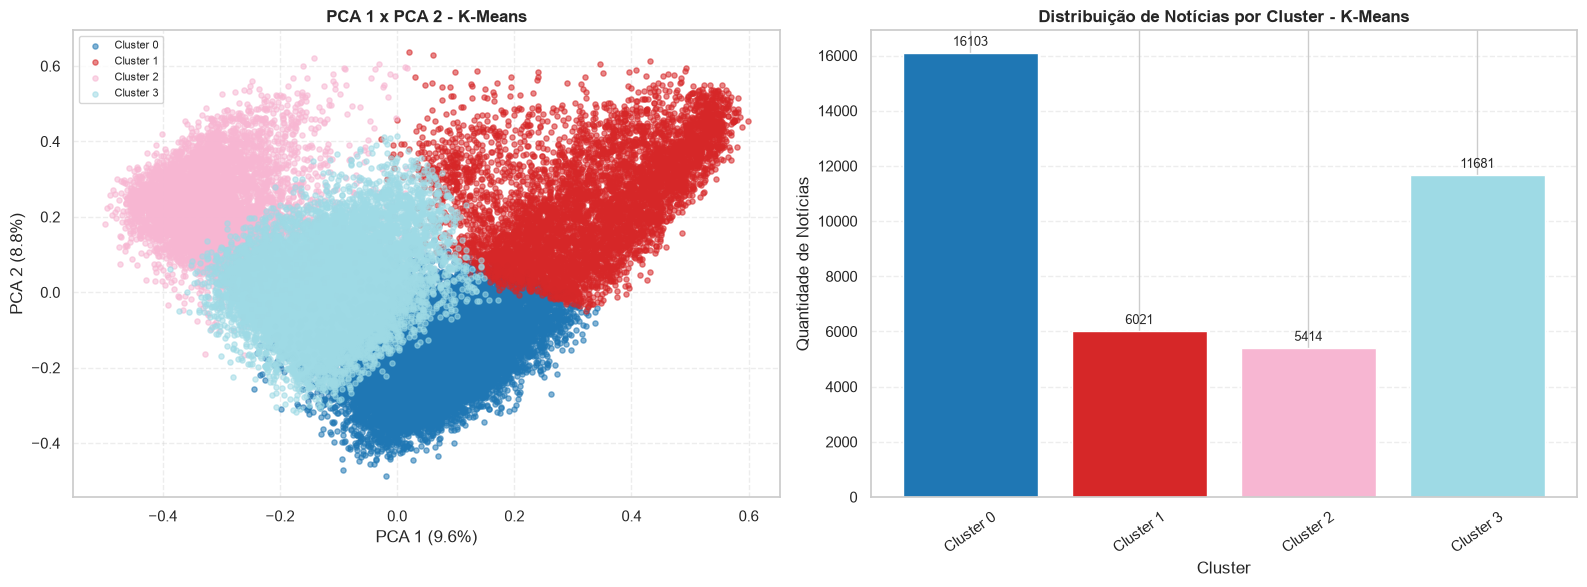

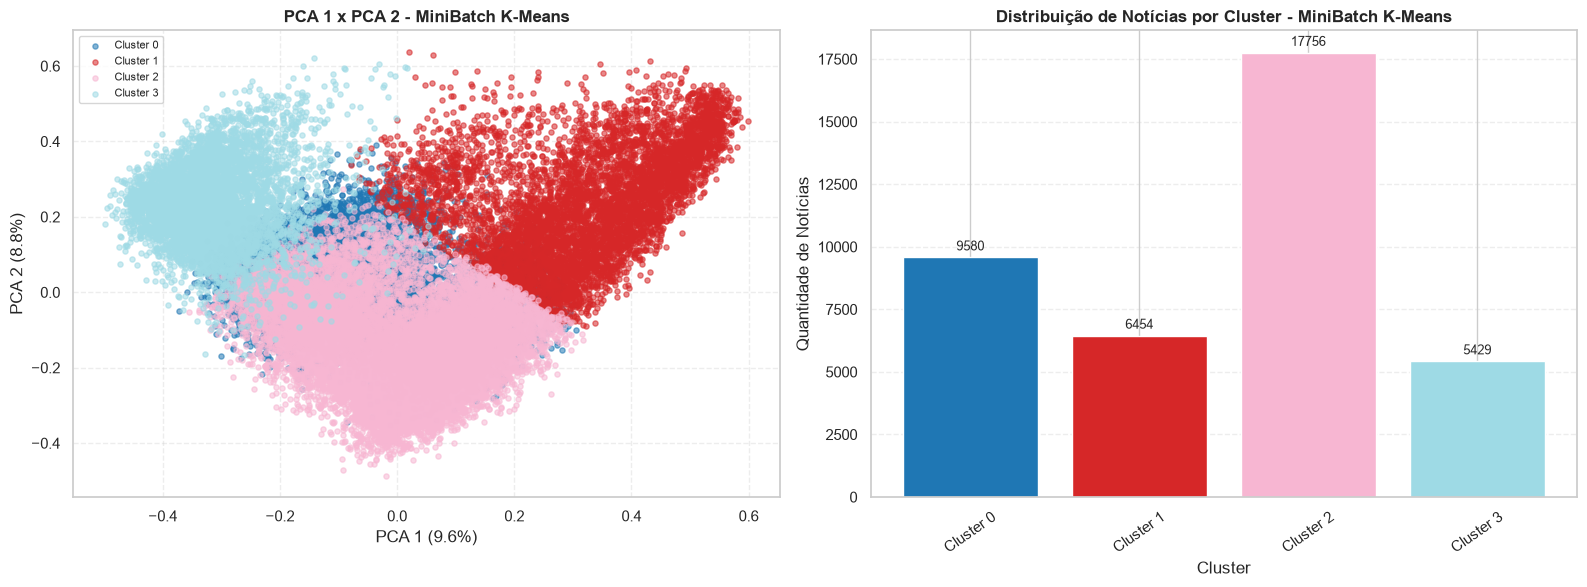

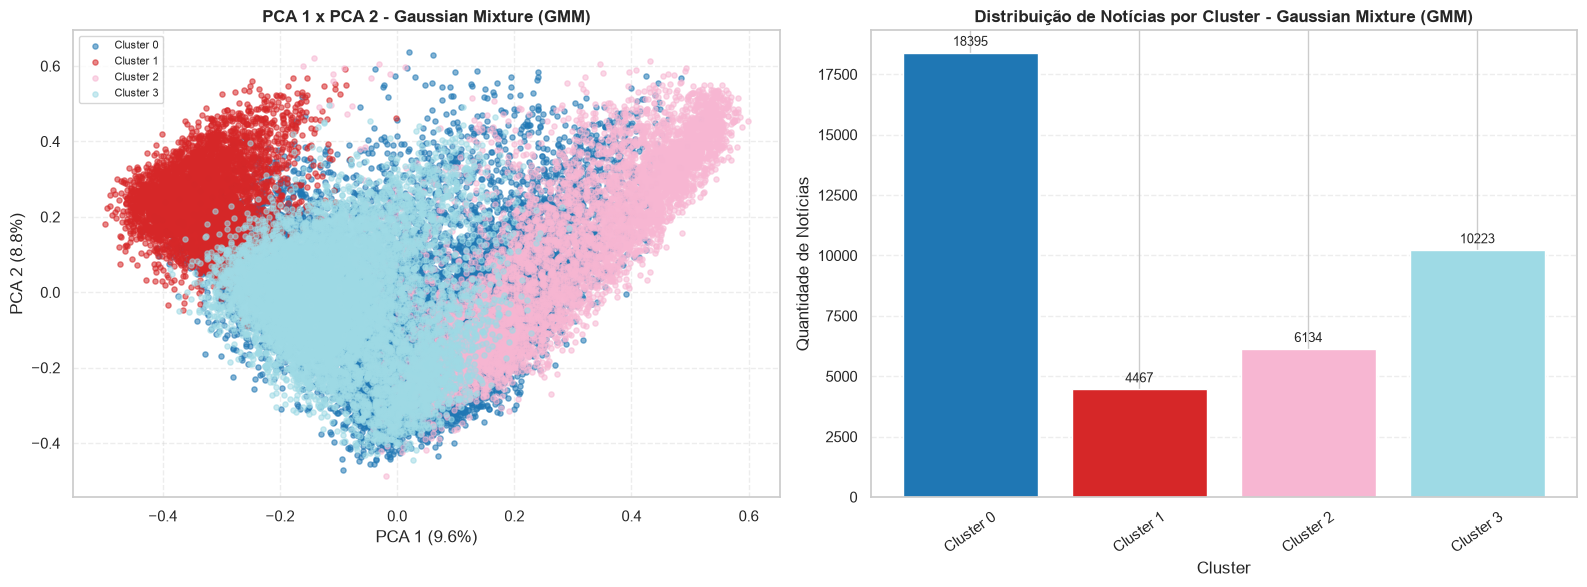

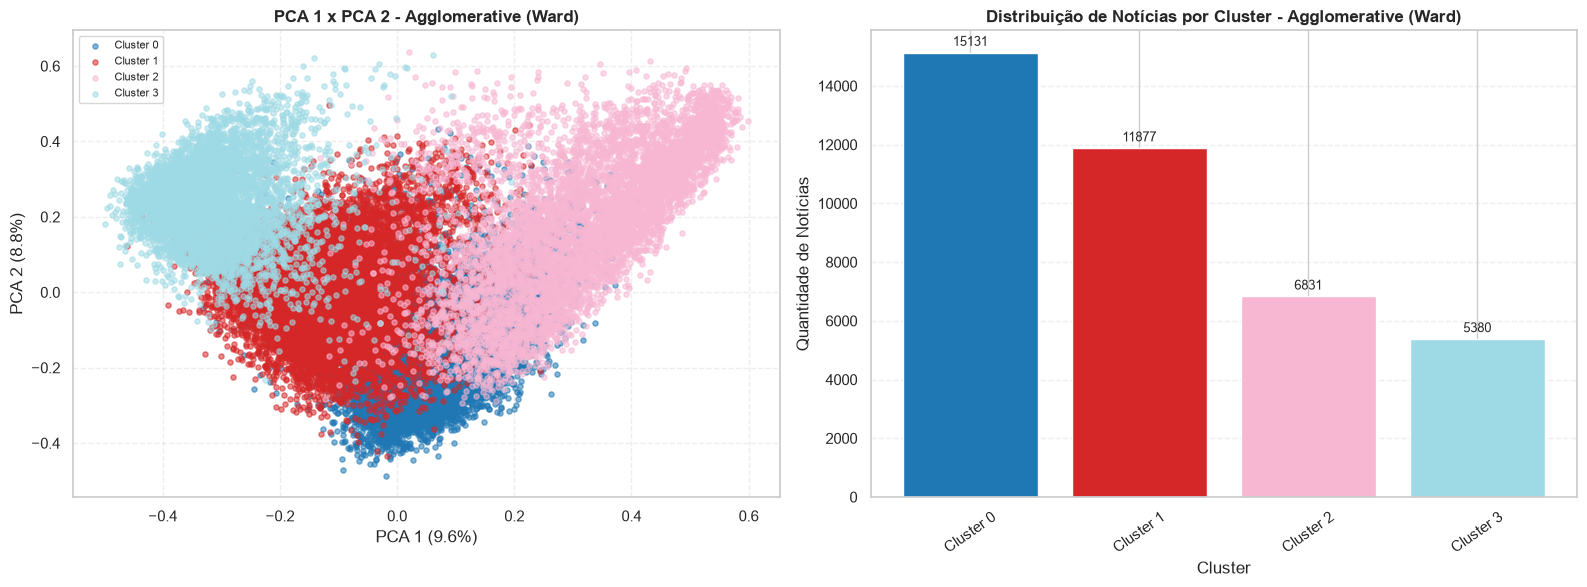

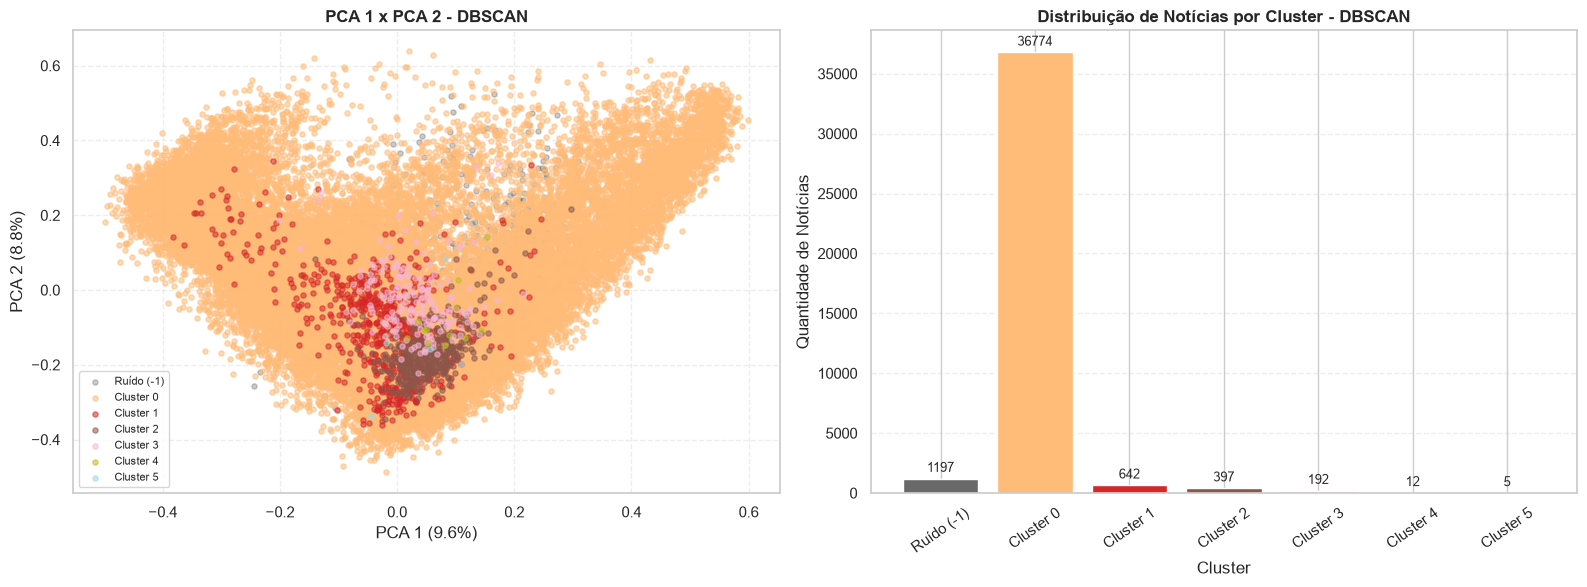

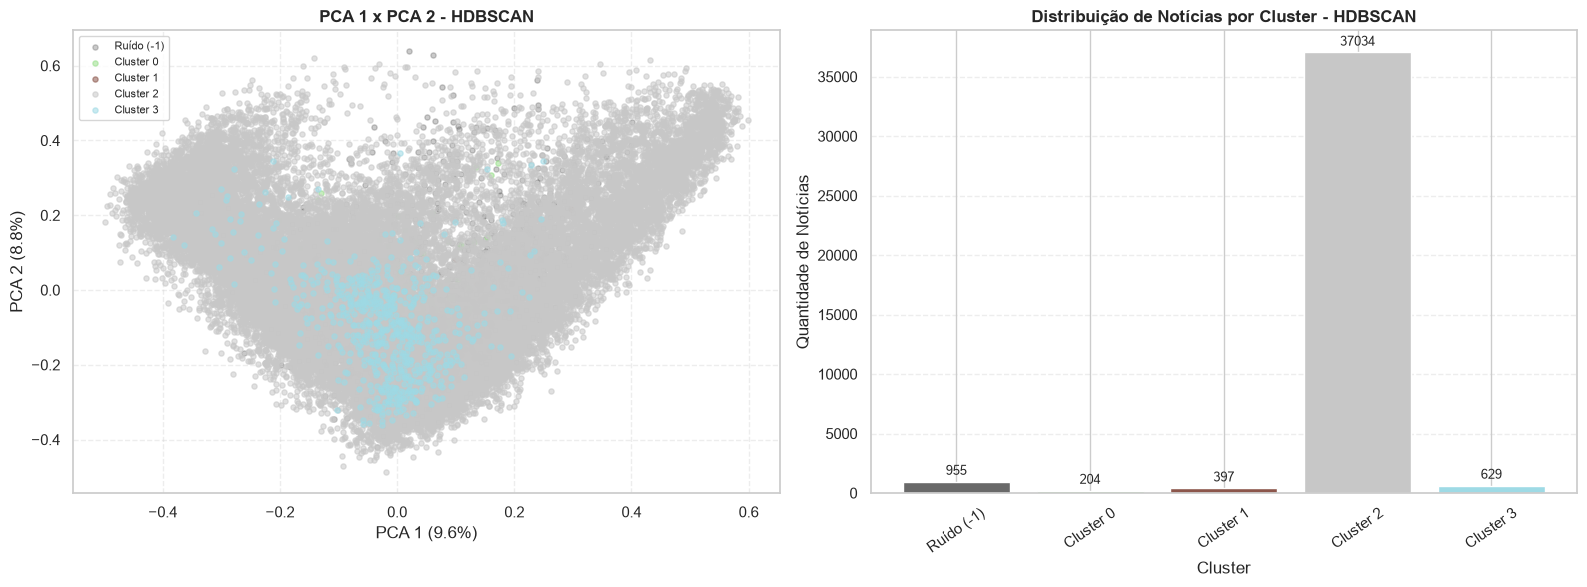

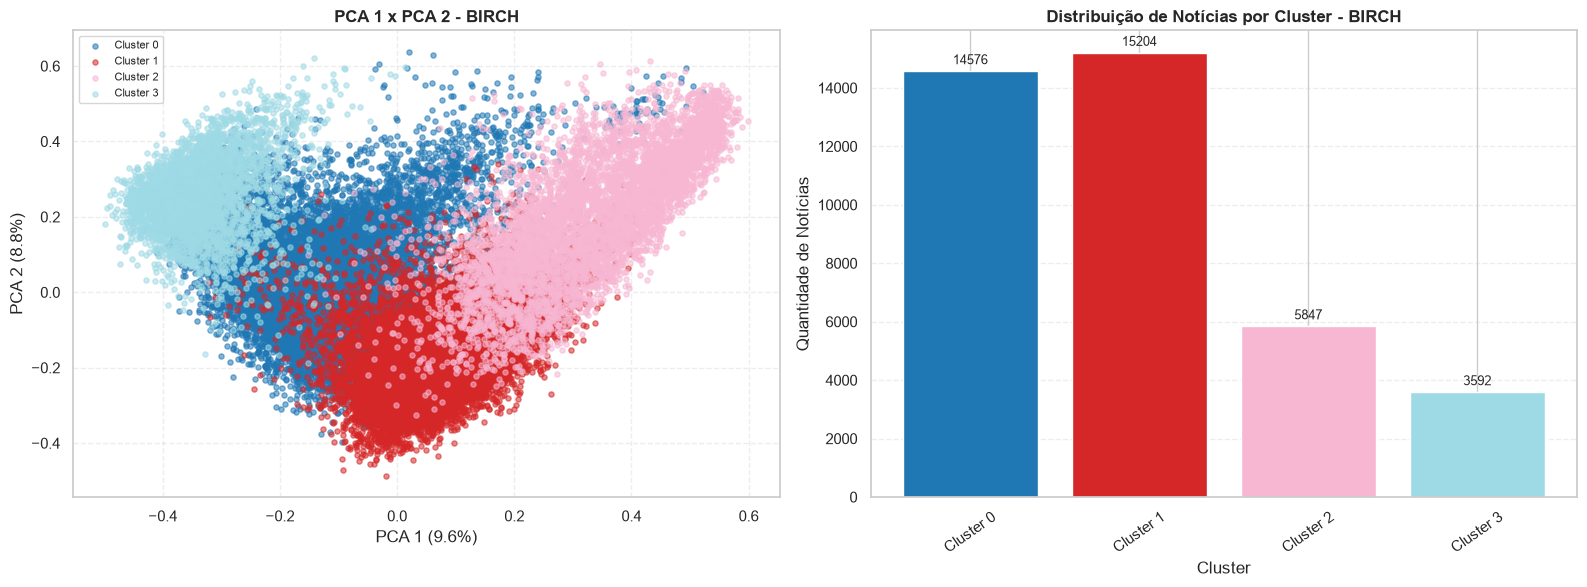

In [11]:
# Projeção PCA 1 x PCA 2 compartilhada por todos os algoritmos
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
coords_pca = pca_2d.fit_transform(X)

for model_name, model_labels in predicted_cluster_labels.items():
    model_labels = np.asarray(model_labels).reshape(-1)
    n_aligned = min(len(model_labels), len(coords_pca))
    labels_aligned = model_labels[:n_aligned]
    coords_aligned = coords_pca[:n_aligned]
    unique_labels = np.sort(np.unique(labels_aligned))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap('tab20', max(len(unique_labels), 1))
    color_map = {
        label: ('dimgray' if label == -1 else cmap(index))
        for index, label in enumerate(unique_labels)
    }

    # PCA 1 x PCA 2 para o algoritmo atual
    for label in unique_labels:
        mask = labels_aligned == label
        label_name = 'Ruído (-1)' if label == -1 else f'Cluster {label}'
        ax1.scatter(
            coords_aligned[mask, 0],
            coords_aligned[mask, 1],
            s=14,
            alpha=0.55 if label != -1 else 0.35,
            color=color_map[label],
            label=label_name
        )

    ax1.set_title(f'PCA 1 x PCA 2 - {model_name}', fontweight='bold')
    ax1.set_xlabel(f'PCA 1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)')
    ax1.set_ylabel(f'PCA 2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.35)

    # Distribuição das notícias por cluster para o algoritmo atual
    counts = pd.Series(labels_aligned).value_counts().sort_index()
    distribution_labels = [
        'Ruído (-1)' if label == -1 else f'Cluster {label}'
        for label in counts.index
    ]
    bars = ax2.bar(
        distribution_labels,
        counts.values,
        color=[color_map[label] for label in counts.index]
    )
    ax2.set_title(f'Distribuição de Notícias por Cluster - {model_name}', fontweight='bold')
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Quantidade de Notícias')
    ax2.tick_params(axis='x', rotation=35)
    ax2.grid(True, axis='y', linestyle='--', alpha=0.35)

    for bar in bars:
        ax2.annotate(
            f'{int(bar.get_height())}',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

    plt.tight_layout()
    plt.show()

### 15. Tabela Comparativa Consolidada, Gráficos e Exportação
___
**O que esta célula faz:**
1. Consolida as métricas intrínsecas de todos os modelos avaliados em um DataFrame formatado.
2. Plota gráficos de barras comparativos (Silhouette e Davies-Bouldin).
3. Exporta as métricas para arquivo `.csv` e salva os rótulos de agrupamento e vizinhança em um arquivo `.npz` para consumo externo.


=== CONSOLIDAÇÃO DOS MODELOS NÃO SUPERVISIONADOS ===
                 Model  N_Clusters  Noise_Ratio_%  Silhouette  Davies_Bouldin  Calinski_Harabasz  Fit_Time_Sec
                DBSCAN           6           3.05      0.0999          1.5940             293.66         2.772
               HDBSCAN           4           2.44      0.0999          1.5670             483.06         6.091
               K-Means           4           0.00      0.0850          2.9828            2794.14         0.859
     MiniBatch K-Means           4           0.00      0.0777          3.5240            2423.46         1.260
  Agglomerative (Ward)           4           0.00      0.0715          3.2680            2451.23         1.397
                 BIRCH           4           0.00      0.0686          3.1564            2355.10        19.416
Gaussian Mixture (GMM)           4           0.00      0.0457          3.7413            1897.63        28.115


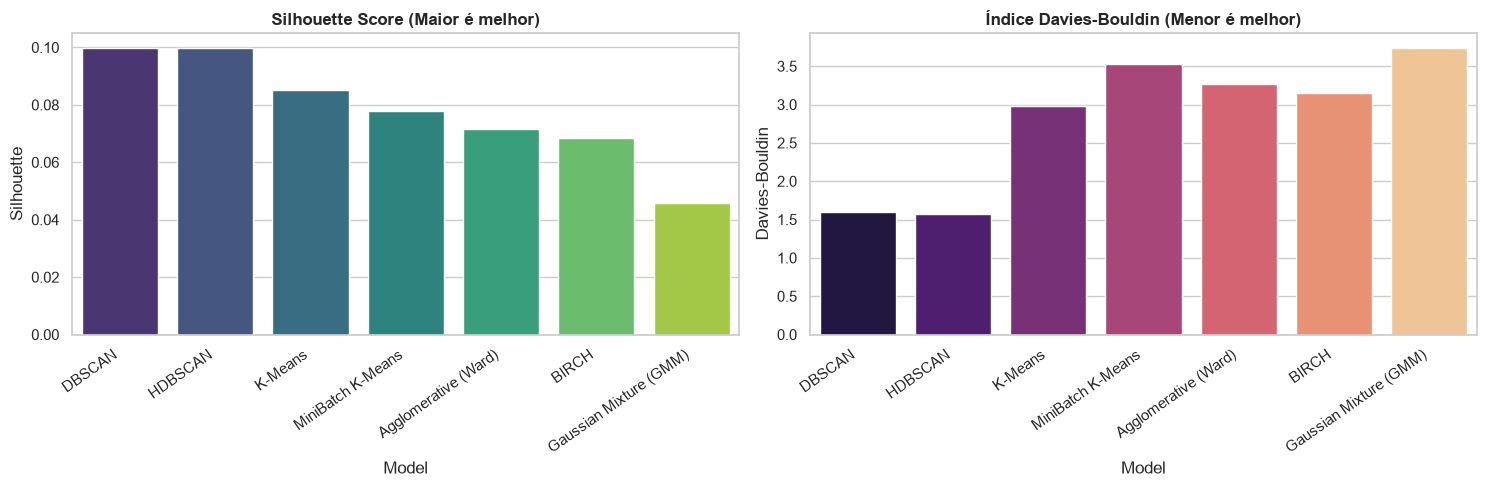

Relatório exportado em: 'results_unsupervised\unsupervised_metrics_20260928_150852.csv'
Rótulos dos clusters salvos em: 'results_unsupervised\unsupervised_clusters.npz'!


In [12]:
df_results = pd.DataFrame(unsupervised_results)
df_results = df_results.sort_values(by='Silhouette', ascending=False, na_position='last').reset_index(drop=True)

print("=== CONSOLIDAÇÃO DOS MODELOS NÃO SUPERVISIONADOS ===")
display_cols = [c for c in ['Model', 'N_Clusters', 'Noise_Ratio_%', 'Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz', 'Fit_Time_Sec'] if c in df_results.columns]
print(df_results[display_cols].to_string(index=False))

# Gráfico Comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Silhouette (Maior é melhor)
sns.barplot(data=df_results.dropna(subset=['Silhouette']), x='Model', y='Silhouette', palette='viridis', ax=ax1)
ax1.set_title('Silhouette Score (Maior é melhor)', fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right')
ax1.set_ylabel('Silhouette')

# Davies-Bouldin (Menor é melhor)
sns.barplot(data=df_results.dropna(subset=['Davies_Bouldin']), x='Model', y='Davies_Bouldin', palette='magma', ax=ax2)
ax2.set_title('Índice Davies-Bouldin (Menor é melhor)', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right')
ax2.set_ylabel('Davies-Bouldin')

plt.tight_layout()
plt.show()

# Exportação do relatório CSV com timestamp
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = os.path.join(OUTPUT_DIR, f"unsupervised_metrics_{ts}.csv")
df_results.to_csv(csv_path, index=False)
print(f"Relatório exportado em: '{csv_path}'")

# Exportação dos clusters atribuídos
export_npz_path = os.path.join(OUTPUT_DIR, "unsupervised_clusters.npz")
export_data = {f"cluster_{name.replace(' ', '_').lower()}": lbls for name, lbls in predicted_cluster_labels.items()}
np.savez_compressed(export_npz_path, **export_data)
print(f"Rótulos dos clusters salvos em: '{export_npz_path}'!")


#### 11. Escolha do modelo final

In [13]:
chosen_model_name = 'K-Means'

### 12. Busca Semântica: Encontrar as 5 Notícias Mais Próximas de Cada Centróide
___
**O que esta célula faz:**
Obtém, para cada centróide dos clusters formados pelo K-Means, as **5 notícias mais próximas** com base na similaridade de cosseno calculada nos embeddings.

**Como funciona a métrica:**
Como os vetores estão com normalização L2 unitária, o produto escalar é a similaridade de cosseno:
$$\text{Similaridade}(\mathbf{u}, \mathbf{v}) = \mathbf{u} \cdot \mathbf{v} \in [-1, 1]$$
Uma pontuação próxima de $100\%$ indica que a notícia está semanticamente muito próxima do centro do cluster.

In [14]:
# Inicialização do motor de busca por proximidade aos centróides
nn_engine = NearestNeighbors(n_neighbors=5, metric='cosine')
nn_engine.fit(X)


def buscar_noticias_proximas_aos_centroides(top_n=5, max_chars=300):
    """Retorna as top_n notícias mais próximas do centróide de cada cluster."""
    cluster_centers = kmeans.cluster_centers_
    n_clusters = len(cluster_centers)
    n_neighbors = min(top_n, len(X))
    results_by_cluster = {}
    indices_by_cluster = {}

    print("=" * 90)
    print(f"TOP-{n_neighbors} NOTÍCIAS MAIS PRÓXIMAS DE CADA CENTRÓIDE")
    print("=" * 90)

    for cluster_id, centroid in enumerate(cluster_centers):
        distances, neighbor_indices = nn_engine.kneighbors(
            centroid.reshape(1, -1),
            n_neighbors=n_neighbors
        )
        distances = distances[0]
        neighbor_indices = neighbor_indices[0]
        indices_by_cluster[cluster_id] = neighbor_indices

        print(f"\n[CLUSTER {cluster_id}]")
        print("-" * 90)
        cluster_results = []

        for rank, (idx, dist) in enumerate(zip(neighbor_indices, distances), start=1):
            cos_similarity = (1.0 - dist) * 100.0
            txt = news_texts[idx] if idx < len(news_texts) else "N/A"
            clean_snip = " ".join(txt.strip().split())
            snip = clean_snip[:max_chars] + ("..." if len(clean_snip) > max_chars else "")

            print(f"#{rank} | Índice: {idx:5d} | Similaridade Cosseno: {cos_similarity:6.2f}%")
            print(f"     \"{snip}\"\n")

            cluster_results.append({
                'Cluster': cluster_id,
                'Rank': rank,
                'Index': int(idx),
                'Similarity_%': round(cos_similarity, 2),
                'Cosine_Distance': round(float(dist), 4),
                'Snippet': snip
            })

        results_by_cluster[cluster_id] = pd.DataFrame(cluster_results)

    df_neighbors = pd.concat(results_by_cluster.values(), ignore_index=True)
    return df_neighbors, indices_by_cluster


# Busca as 5 notícias mais próximas do centróide de cada cluster.
df_neighbors, top_indices_by_cluster = buscar_noticias_proximas_aos_centroides(top_n=5)


TOP-5 NOTÍCIAS MAIS PRÓXIMAS DE CADA CENTRÓIDE

[CLUSTER 0]
------------------------------------------------------------------------------------------
#1 | Índice: 36366 | Similaridade Cosseno:  88.67%
     "Olhando todos esses fatos fica fácil entender porquê nem o próprio CEO quer tomar a vacina, mas você é obrigado tomar, segundo o STF. Você vai tomar?”"

#2 | Índice: 27841 | Similaridade Cosseno:  88.27%
     "CoronaVac é proibido (sic) nos EUA e na Europa. Por isso que Bolsonaro não queria a Vacina Chinesa"

#3 | Índice: 20160 | Similaridade Cosseno:  87.96%
     ""Dane-se o povo e os cadáveres, se o vírus cumprir 'sua missão' de 'abreviar' o governo, tudo está bem." Fernanda Torres"

#4 | Índice:  5446 | Similaridade Cosseno:  87.92%
     "A saber. o filho de Carlos Slim, o mexicano mais rico do mundo, dono da Claro e co-proprietário do Grupo Globo de Comunicações, esteve no Rio de Janeiro e em Brasília. Em terras cariocas reuniu a direção do Grupo Globo e determinou que parassem

### 13. Visualização da Vizinhança Semântica e Projeções 2D
___
**O que esta célula faz:**
1. Projeta as notícias em um plano bidimensional via **PCA** e **t-SNE**.
2. **Destaque Visual da Consulta:** Destaca a notícia consultada (`QUERY_INDEX`) com uma estrela vermelha ($\bigstar$) e seus vizinhos mais próximos com marcadores especiais, ilustrando a coerência geométrica no espaço latente.
3. Exibe painel com a distribuição global de todos os clusters identificados.


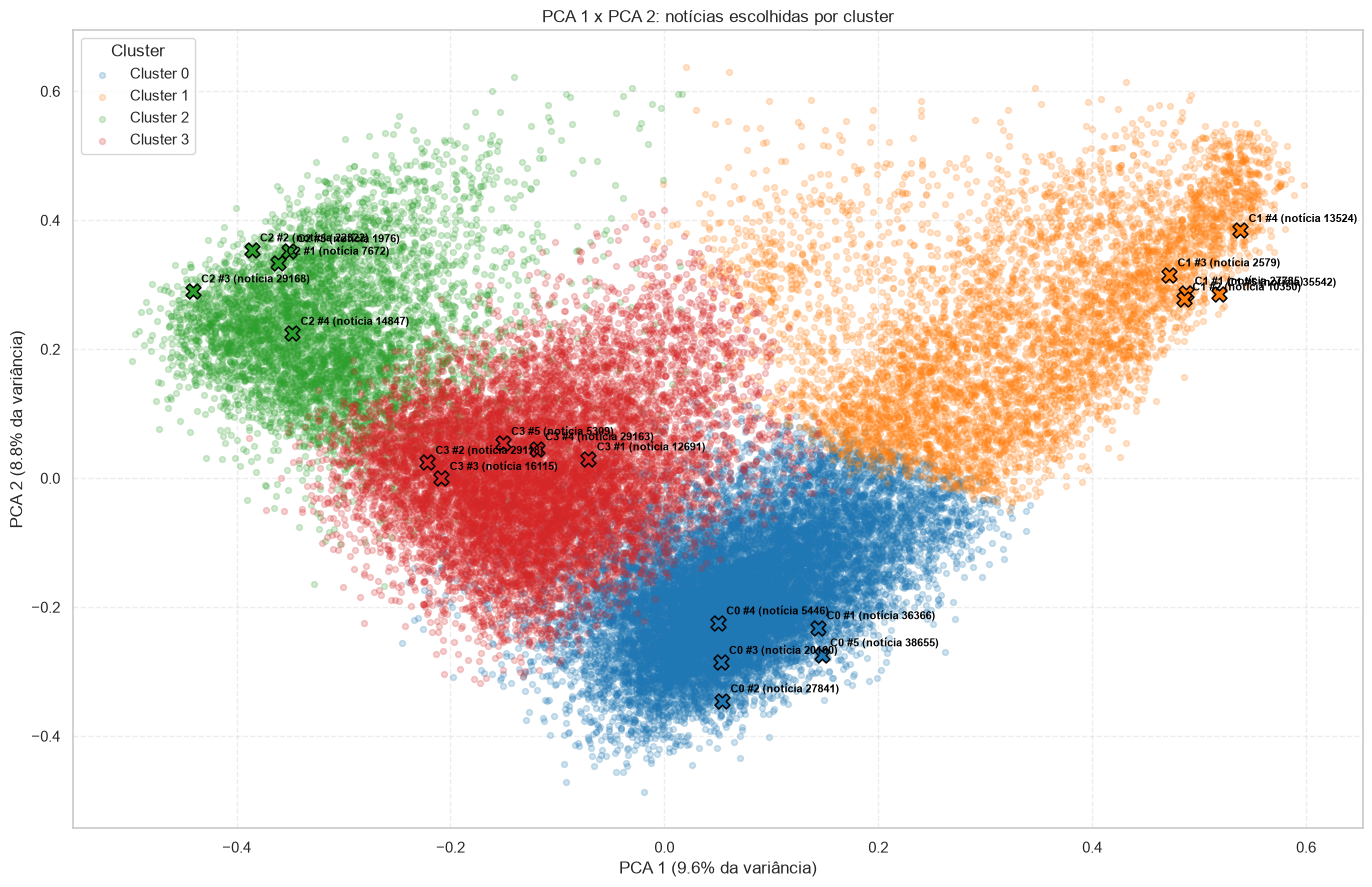

In [15]:
# PCA 1 x PCA 2 com as notícias escolhidas para cada cluster
cluster_labels_plot = np.asarray(labels_kmeans).reshape(-1)
n_points = min(len(coords_pca), len(cluster_labels_plot))
plot_coords = coords_pca[:n_points]
plot_labels = cluster_labels_plot[:n_points]

fig, ax = plt.subplots(figsize=(14, 9))
cluster_ids = sorted(top_indices_by_cluster)
cluster_colors = sns.color_palette('tab10', n_colors=max(len(cluster_ids), 1))

# Contexto: todas as notícias, coloridas pelo cluster atribuído pelo K-Means.
for color, cluster_id in zip(cluster_colors, cluster_ids):
    mask = plot_labels == cluster_id
    ax.scatter(
        plot_coords[mask, 0], plot_coords[mask, 1],
        s=18, alpha=0.22, color=color, label=f'Cluster {cluster_id}'
    )

# Destaque das notícias selecionadas próximas a cada centróide.
for color, cluster_id in zip(cluster_colors, cluster_ids):
    selected_indices = [int(idx) for idx in top_indices_by_cluster[cluster_id] if int(idx) < n_points]
    selected_coords = plot_coords[selected_indices]
    ax.scatter(
        selected_coords[:, 0], selected_coords[:, 1],
        s=115, color=color, edgecolors='black', linewidths=1.1,
        marker='X', zorder=4
    )

    for rank, idx in enumerate(selected_indices, start=1):
        ax.annotate(
            f'C{cluster_id} #{rank} (notícia {idx})',
            (plot_coords[idx, 0], plot_coords[idx, 1]),
            xytext=(6, 6), textcoords='offset points',
            fontsize=8, fontweight='bold', color='black', zorder=5
        )

ax.set_title('PCA 1 x PCA 2: notícias escolhidas por cluster')
ax.set_xlabel(f'PCA 1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% da variância)')
ax.set_ylabel(f'PCA 2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% da variância)')
ax.legend(title='Cluster', loc='best')
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### 16. Nuvem de Palavras por Cluster
___
**O que esta célula faz:**
Gera uma nuvem de palavras para cada cluster do modelo escolhido, removendo palavras muito comuns em português para destacar os termos mais frequentes e representativos de cada agrupamento.


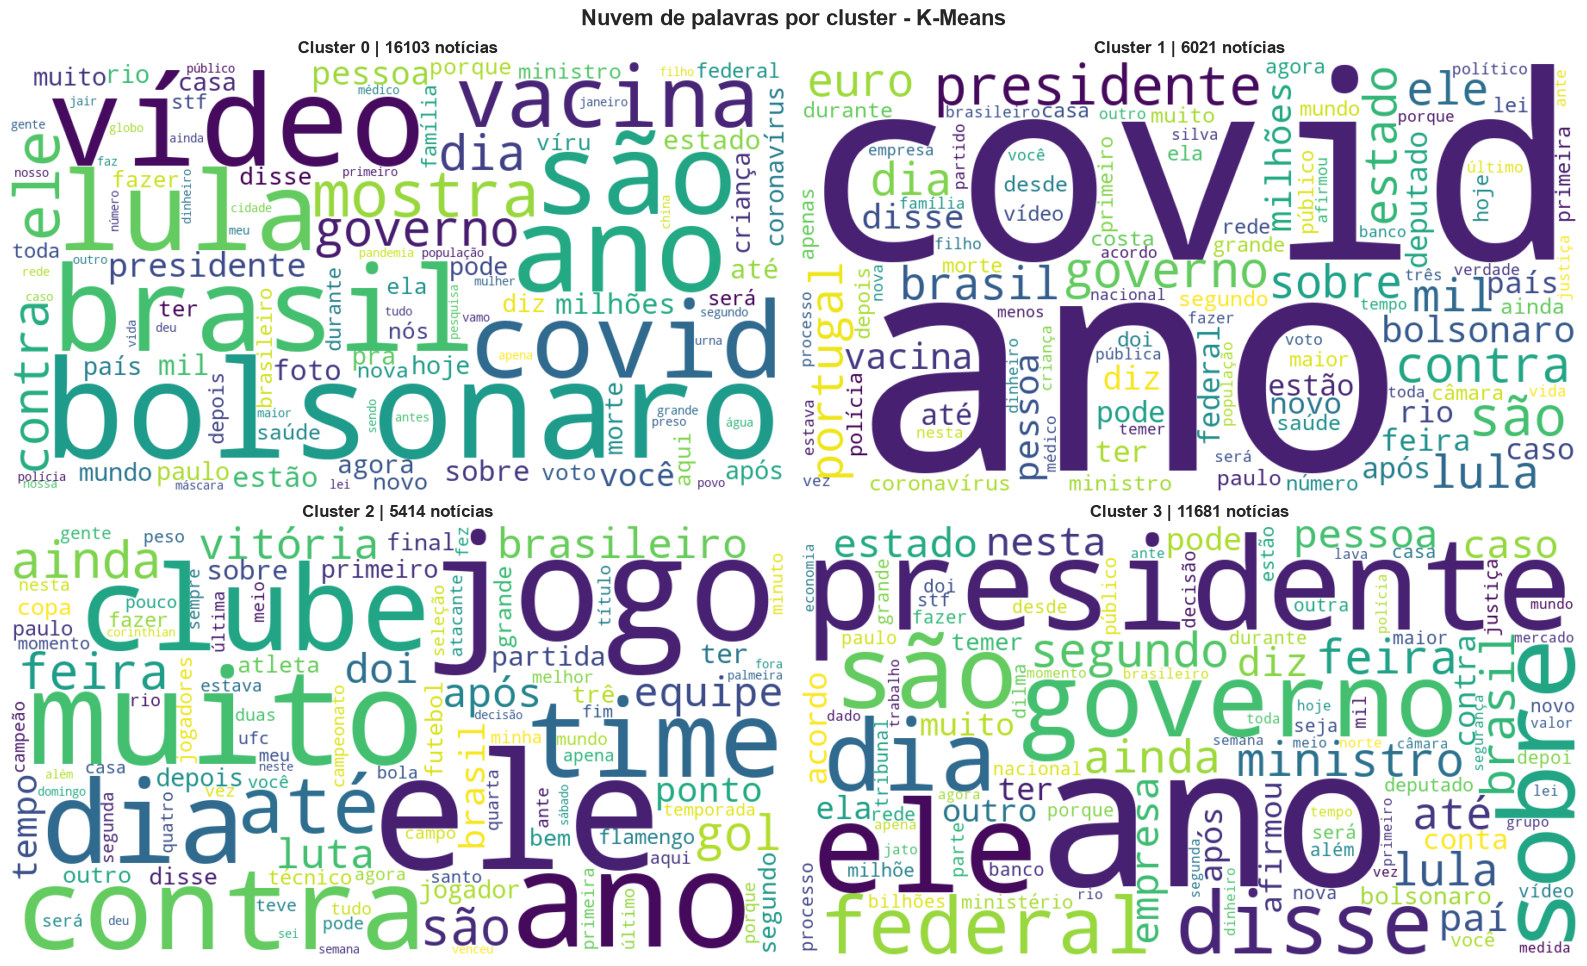

In [16]:
import re
import unicodedata
from wordcloud import WordCloud, STOPWORDS

# Stopwords em português para manter apenas termos informativos.
portuguese_stopwords = {
    'a', 'ao', 'aos', 'as', 'à', 'às', 'com', 'como', 'da', 'das', 'de', 'do',
    'dos', 'e', 'é', 'em', 'entre', 'era', 'essa', 'essas', 'esse', 'esses',
    'esta', 'está', 'estas', 'este', 'estes', 'foi', 'foram', 'há', 'isso',
    'isto', 'já', 'mais', 'mas', 'mesmo', 'na', 'nas', 'nem', 'no', 'nos',
    'num', 'numa', 'não', 'o', 'os', 'ou', 'para', 'pela', 'pelas', 'pelo',
    'pelos', 'por', 'qual', 'quando', 'que', 'quem', 'se', 'sem', 'ser',
    'seu', 'seus', 'sua', 'suas', 'também', 'tem', 'têm', 'todo', 'todos',
    'um', 'uma', 'uns', 'umas', 'vai', 'vão'
}
stopwords = set(STOPWORDS).union(portuguese_stopwords)


def preparar_texto_nuvem(texto):
    texto = unicodedata.normalize('NFKC', str(texto)).lower()
    palavras = re.findall(r'[a-zà-ÿ]{3,}', texto, flags=re.IGNORECASE)
    return ' '.join(palavra for palavra in palavras if palavra not in stopwords)


cluster_labels = np.asarray(predicted_cluster_labels[chosen_model_name]).reshape(-1)
n_aligned = min(len(cluster_labels), len(news_texts))
cluster_labels = cluster_labels[:n_aligned]
cluster_texts = [str(texto) for texto in news_texts[:n_aligned]]
cluster_ids = sorted(np.unique(cluster_labels).tolist())

n_columns = 2
n_rows = max(1, int(np.ceil(len(cluster_ids) / n_columns)))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for axis, cluster_id in zip(axes, cluster_ids):
    texts = [cluster_texts[index] for index in np.where(cluster_labels == cluster_id)[0]]
    text_for_cloud = ' '.join(preparar_texto_nuvem(texto) for texto in texts).strip()
    cluster_title = 'Ruído (-1)' if cluster_id == -1 else f'Cluster {cluster_id}'

    if text_for_cloud:
        cloud = WordCloud(
            width=900,
            height=500,
            background_color='white',
            colormap='viridis',
            max_words=100,
            collocations=False,
            random_state=RANDOM_STATE
        ).generate(text_for_cloud)
        axis.imshow(cloud, interpolation='bilinear')
    else:
        axis.text(0.5, 0.5, 'Sem palavras suficientes', ha='center', va='center')

    axis.set_title(f'{cluster_title} | {np.sum(cluster_labels == cluster_id)} notícias', fontweight='bold')
    axis.axis('off')

for axis in axes[len(cluster_ids):]:
    axis.axis('off')

fig.suptitle(f'Nuvem de palavras por cluster - {chosen_model_name}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


=== DISTRIBUIÇÃO DE VERACIDADE POR CLUSTER ===
Contagens absolutas:


col_0,Falsa,Verdadeira
row_0,,
0,14454,1649
1,4493,1528
2,82,5332
3,4175,7506


Percentuais dentro de cada cluster:


col_0,Falsa,Verdadeira
row_0,,
0,89.76,10.24
1,74.62,25.38
2,1.51,98.49
3,35.74,64.26


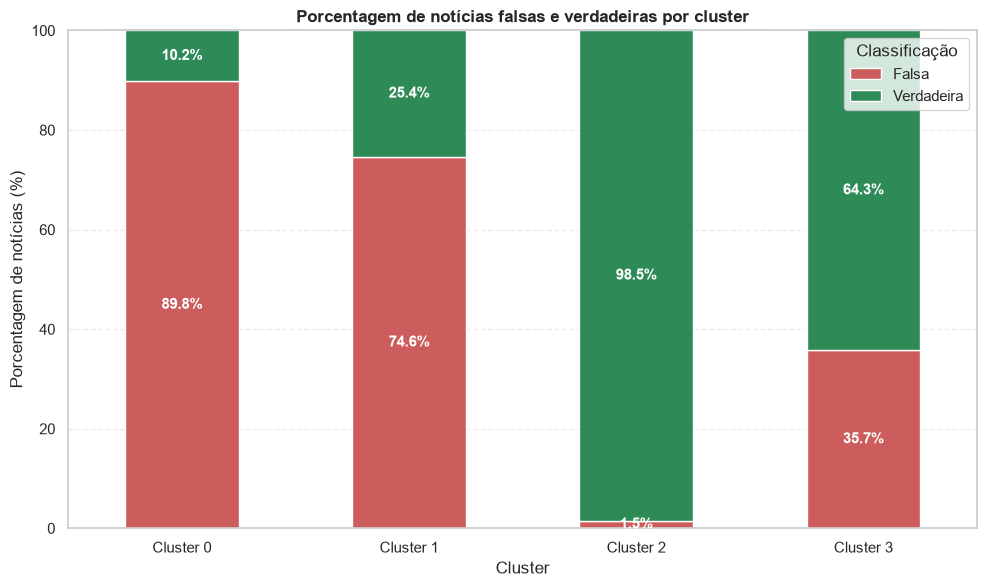

Resumo exportado em: 'results_unsupervised\truth_distribution_by_cluster.csv'


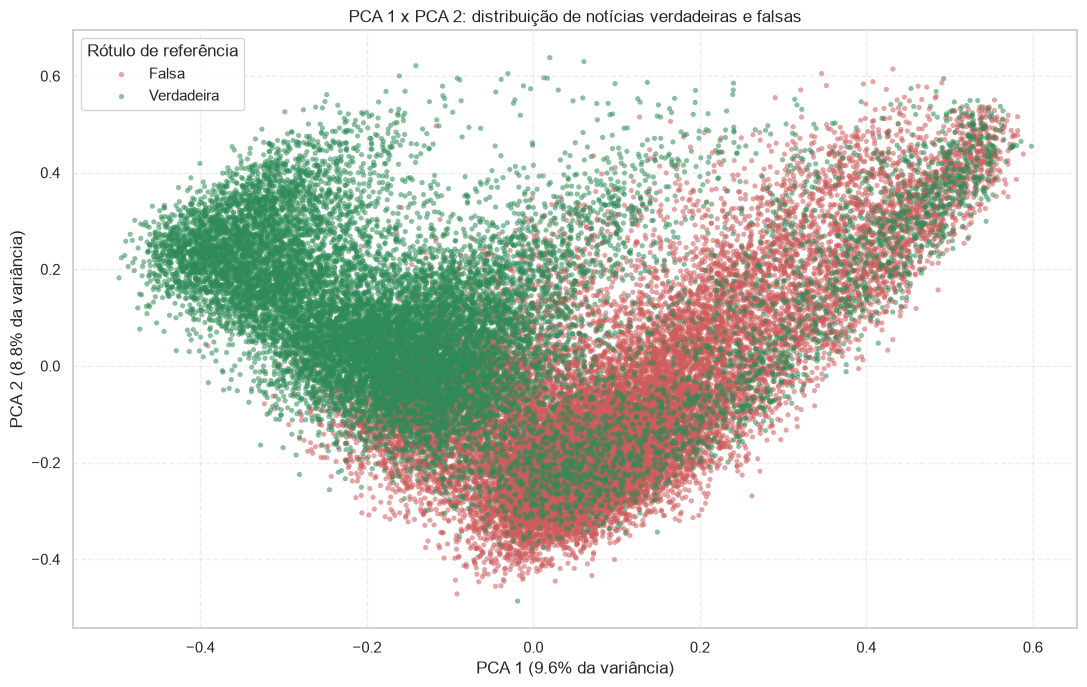

In [17]:
# Distribuição de veracidade por cluster e projeção PCA 1 x PCA 2
if y_true is None:
    print("Os rótulos de referência (y_true) não estão disponíveis no arquivo de embeddings.")
else:
    labels_ref = np.asarray(y_true).reshape(-1)
    labels_cluster = np.asarray(predicted_cluster_labels[chosen_model_name]).reshape(-1)
    n_aligned = min(len(labels_ref), len(labels_cluster), len(coords_pca))

    def normalizar_rotulo_veracidade(label):
        valor = str(label).strip().lower()
        if valor in {'1', 'true', 'verdadeiro', 'verdadeira', 'real', 'real news'}:
            return 'Verdadeira'
        if valor in {'0', 'false', 'falso', 'falsa', 'fake', 'fake news'}:
            return 'Falsa'
        return str(label)

    truth_labels = np.array([
        normalizar_rotulo_veracidade(label)
        for label in labels_ref[:n_aligned]
    ])
    cluster_labels_aligned = labels_cluster[:n_aligned]

    distribution_counts = pd.crosstab(
        cluster_labels_aligned,
        truth_labels
    ).sort_index()
    distribution_percent = distribution_counts.div(
        distribution_counts.sum(axis=1), axis=0
    ).mul(100).round(2)

    print('=== DISTRIBUIÇÃO DE VERACIDADE POR CLUSTER ===')
    print('Contagens absolutas:')
    display(distribution_counts)
    print('Percentuais dentro de cada cluster:')
    display(distribution_percent)

    # Gráfico de barras empilhadas com a porcentagem por cluster.
    truth_order = [label for label in ['Falsa', 'Verdadeira'] if label in distribution_percent.columns]
    chart_data = distribution_percent.reindex(columns=truth_order, fill_value=0)
    ax = chart_data.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6),
        color=['indianred', 'seagreen']
    )
    ax.set_title('Porcentagem de notícias falsas e verdadeiras por cluster', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Porcentagem de notícias (%)')
    ax.set_ylim(0, 100)
    ax.set_xticklabels([f'Cluster {cluster}' for cluster in chart_data.index], rotation=0)
    ax.legend(title='Classificação')
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',
            label_type='center',
            color='white',
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    df_cluster_truth_summary = distribution_counts.copy()
    for column in distribution_percent.columns:
        df_cluster_truth_summary[f'{column}_%'] = distribution_percent[column]

    truth_summary_path = os.path.join(OUTPUT_DIR, 'truth_distribution_by_cluster.csv')
    df_cluster_truth_summary.to_csv(truth_summary_path, index=True)
    print(f"Resumo exportado em: '{truth_summary_path}'")

    # Scatterplot PCA 1 x PCA 2 colorido pelo rótulo de veracidade.
    truth_colors = {'Verdadeira': 'seagreen', 'Falsa': 'indianred'}
    fig, ax = plt.subplots(figsize=(11, 7))
    for truth_value in pd.unique(truth_labels):
        mask = truth_labels == truth_value
        ax.scatter(
            coords_pca[:n_aligned, 0][mask],
            coords_pca[:n_aligned, 1][mask],
            s=14,
            alpha=0.55,
            c=truth_colors.get(truth_value, 'steelblue'),
            label=truth_value,
            edgecolors='none'
        )

    ax.set_title('PCA 1 x PCA 2: distribuição de notícias verdadeiras e falsas')
    ax.set_xlabel(f'PCA 1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% da variância)')
    ax.set_ylabel(f'PCA 2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% da variância)')
    ax.legend(title='Rótulo de referência')
    ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()

### 14. Detecção de Anomalias e Notícias com Conteúdo Fora do Padrão
___
**O que esta célula faz:**
Aplica **Isolation Forest** e **Local Outlier Factor (LOF)** para identificar notícias semântica ou estruturalmente isoladas (textos fora do padrão, formatos raros ou notícias marginais com vocabulário atípico).


In [18]:
# 1. Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
outliers_iso = iso_forest.fit_predict(X_pca)

# Score de anormalidade para cada notícia (valores mais negativos = mais atípicos)
anomaly_scores = iso_forest.decision_function(X_pca)

n_outliers = np.sum(outliers_iso == -1)
print(f"Isolation Forest: {n_outliers} notícias atípicas identificadas ({n_outliers/len(X)*100:.2f}%)")

# Ordena as notícias atípicas pela maior anormalidade (score mais negativo = mais anômala)
outlier_indices = np.where(outliers_iso == -1)[0]
outlier_score_pairs = sorted(
    [(idx, anomaly_scores[idx]) for idx in outlier_indices],
    key=lambda x: x[1]
)

print("\nTop 5 notícias mais atípicas:")
for rank, (out_idx, score) in enumerate(outlier_score_pairs[:5], start=1):
    txt_sample = news_texts[out_idx] if out_idx < len(news_texts) else "N/A"
    clean_sample = " ".join(txt_sample.strip().split())
    print(f"[{rank}] Notícia #{out_idx} | Score de anormalidade: {score:.4f}")
    print(f"    \"{clean_sample}\"\n")


Isolation Forest: 1177 notícias atípicas identificadas (3.00%)

Top 5 notícias mais atípicas:
[1] Notícia #6994 | Score de anormalidade: -0.0662
    "Astronauta austríaco salta de uma espaçonave para chegar à Terra"

[2] Notícia #39045 | Score de anormalidade: -0.0618
    "A sonda Perseverance fotografou o alinhamento da Terra, Vênus e Júpiter em Marte"

[3] Notícia #13778 | Score de anormalidade: -0.0609
    "Esta fotografia retrata a Proxima Centauri, estrela mais próxima do Sol."

[4] Notícia #9778 | Score de anormalidade: -0.0571
    "Onde estão e de que são feitos os milhares de asteroides que povoam o Sistema Solar. Três cinturões concentram a maioria desses corpos; pertubações em sua órbita podem colocá-los em rota de colisão com a Terra.. No dia 19 de outubro passado, os telescópios detectaram um visitante inesperado: o primeiro asteroide interestelar de que se tem notícia a passar pelo Sistema Solar. Com um formato que lembra um charuto, com cerca de 400 metros de cumprimento 

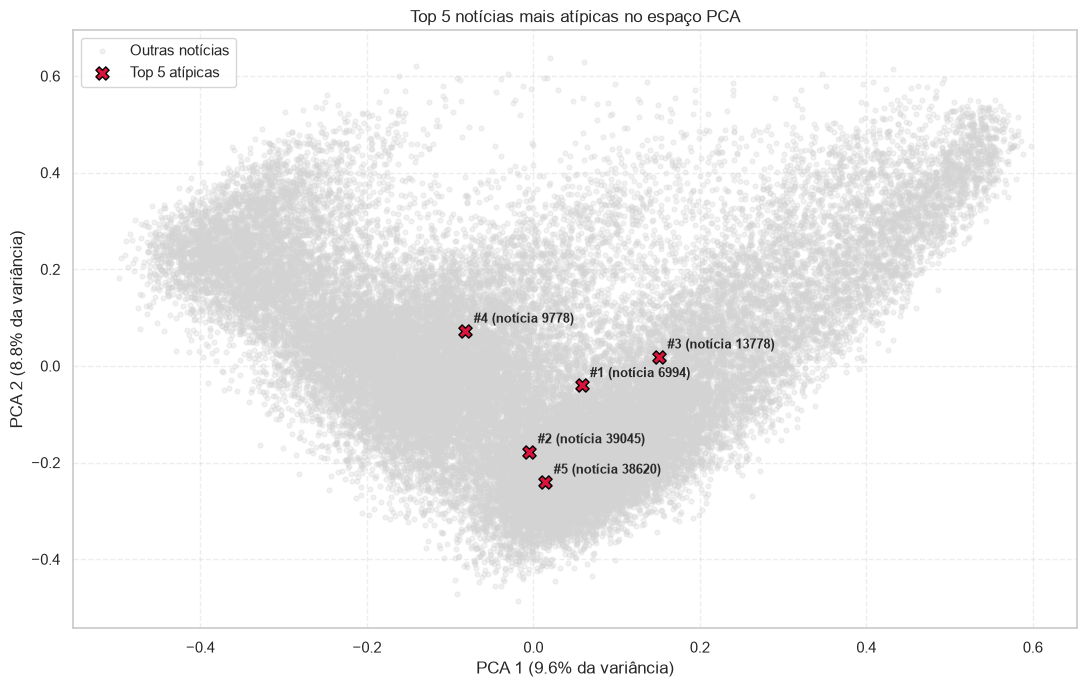

In [19]:
# Visualização das cinco notícias mais atípicas no plano PCA 1 x PCA 2
top_outlier_pairs = outlier_score_pairs[:5]
top_indices = [idx for idx, _ in top_outlier_pairs]

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c='lightgray', s=12, alpha=0.3, label='Outras notícias'
 )

if top_indices:
    top_coords = coords_pca[top_indices]
    ax.scatter(
        top_coords[:, 0], top_coords[:, 1],
        c='crimson', s=90, marker='X', edgecolors='black',
        linewidths=1.0, label='Top 5 atípicas', zorder=3
    )
    for rank, (out_idx, score) in enumerate(top_outlier_pairs, start=1):
        ax.annotate(
            f'#{rank} (notícia {out_idx})',
            (coords_pca[out_idx, 0], coords_pca[out_idx, 1]),
            xytext=(6, 6), textcoords='offset points',
            fontsize=9, fontweight='bold'
        )

ax.set_title('Top 5 notícias mais atípicas no espaço PCA')
ax.set_xlabel(f'PCA 1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% da variância)')
ax.set_ylabel(f'PCA 2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% da variância)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()